In this section I try to justify the better performance of LTH as a compression method showing that 
1) Lottery tickets have higher CKA with their dense model counterpart than student models have with teacher model counterpart; To do this I will train some tickets starting form the same dense model and same dense inizialization differentating the tickets by randomizing the Gradient descent by randomazing the data loader order, I will do the same to obtain some students models startitng form the same Teacher. Then I will show the average CKA between Dense model and tikets and the average CKA between Teacher and students. If lottery tickets mantain higher CKA than Students this means that LT learn representations more alligned with the Bigger model
2) For the models trained as in last point I will also verify LMC between the Dense and the sparse models as per paper Frankle et al., “Linear Mode Connectivity and the Lottery Ticket Hypothesis” (ICML 2020) LMC between the models should exist and show that dense and tickets models are functionally alligned, this is surprising because the Dense and sparse model are different but the intuition comes from the fact that the sparse model could "live" in a sub-space of aproximabkle functions of the space of the dense model, this is not trivial for KD since Teacher and Student model are two modesls completely unrelated and for this reason is not even possible to interpolate the two models to verify LMC as defined in the Frankle et al. paper.

In [1]:
import torch
import wandb
from torch.optim.lr_scheduler import CosineAnnealingLR
from training import train_epoch, eval_epoch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune

from cka_utils import compute_cka_matrix

from lth_utils import get_prunable_layers, train_model, remove_pruning_reparam, count_sparsity, count_active_parameters

from models import TeacherCNN, StudentCNN, BigCNN

In [2]:

from mnist1d_dataset import get_mnist1d_loaders, get_dataset_info

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader, test_loader = get_mnist1d_loaders()

info = get_dataset_info()
print(info)

File already exists. Skipping download.
Successfully loaded data from ./mnist1d_data.pkl
File already exists. Skipping download.
Successfully loaded data from ./mnist1d_data.pkl
{'n_train': 4000, 'n_test': 1000, 'input_length': 40, 'num_classes': 10}


## KD Training

In [58]:
wandb.init(
    project="mnist-1d-KDvsLTH",
    group="TeacherCNN",
    name="TeacherCNN",
    config={
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "epochs": 500,
        "patience": 50,
        "architecture": "TeacherCNN",
        "scheduler": "CosineAnnealingLR"
    }
)

teacher = TeacherCNN().to(device)
optimizer = torch.optim.Adam(teacher.parameters(), lr=wandb.config.learning_rate, weight_decay=wandb.config.weight_decay)
scheduler = CosineAnnealingLR(optimizer, T_max=wandb.config.epochs)
criterion = nn.CrossEntropyLoss()
epochs = wandb.config.epochs
#early_stopper = EarlyStopping(patience=wandb.config.patience)

wandb.watch(teacher, log_freq=100)

best_test_acc = 0.0
model_path = "best_teacher_model.pth"

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(teacher, train_loader, optimizer, criterion, device)
    test_loss, test_acc = eval_epoch(teacher, test_loader, criterion, device)

    # Step the scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    wandb.log({
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "learning_rate": current_lr
    }, step=epoch)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(teacher.state_dict(), model_path)
        wandb.save(model_path)

    # Check Early Stopping
    #early_stopper(test_loss)
    #if early_stopper.early_stop:
    #    print(f"Early stopping triggered at epoch {epoch+1}")
    #    break

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Acc: {test_acc:.3f} | LR: {current_lr:.6f}")

print("\nTraining complete.")

teacher.load_state_dict(torch.load(model_path))

final_loss, final_acc = eval_epoch(teacher, test_loader, nn.CrossEntropyLoss(), device)

wandb.log({
    "best_test_loss": final_loss,
    "best_test_acc": final_acc
})

print(f"Best Teacher model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

wandb.finish()

wandb: Currently logged in as: matteo-piras (matteo-piras-universit-di-firenze) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch 010 | Acc: 0.956 | LR: 0.000999
Epoch 020 | Acc: 0.974 | LR: 0.000996
Epoch 030 | Acc: 0.978 | LR: 0.000991
Epoch 040 | Acc: 0.972 | LR: 0.000984
Epoch 050 | Acc: 0.984 | LR: 0.000976
Epoch 060 | Acc: 0.983 | LR: 0.000965
Epoch 070 | Acc: 0.982 | LR: 0.000952
Epoch 080 | Acc: 0.983 | LR: 0.000938
Epoch 090 | Acc: 0.985 | LR: 0.000922
Epoch 100 | Acc: 0.986 | LR: 0.000905
Epoch 110 | Acc: 0.980 | LR: 0.000885
Epoch 120 | Acc: 0.985 | LR: 0.000864
Epoch 130 | Acc: 0.987 | LR: 0.000842
Epoch 140 | Acc: 0.986 | LR: 0.000819
Epoch 150 | Acc: 0.987 | LR: 0.000794
Epoch 160 | Acc: 0.985 | LR: 0.000768
Epoch 170 | Acc: 0.980 | LR: 0.000741
Epoch 180 | Acc: 0.987 | LR: 0.000713
Epoch 190 | Acc: 0.987 | LR: 0.000684
Epoch 200 | Acc: 0.985 | LR: 0.000655
Epoch 210 | Acc: 0.989 | LR: 0.000624
Epoch 220 | Acc: 0.988 | LR: 0.000594
Epoch 230 | Acc: 0.989 | LR: 0.000563
Epoch 240 | Acc: 0.988 | LR: 0.000531
Epoch 250 | Acc: 0.987 | LR: 0.000500
Epoch 260 | Acc: 0.989 | LR: 0.000469
Epoch 270 | 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best_test_acc,▁
best_test_loss,▁
learning_rate,████████▇▇▇▆▆▆▆▆▆▆▆▆▅▅▄▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
test_acc,▁▅▆▇▇███████████████████████████████████
test_loss,█▂▂▂▂▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▂▃▆▇▆▅▆▇▇▇▇▇█████▇█████████████████████
train_loss,█▃▃▂▃▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_test_acc,0.992
best_test_loss,0.03748
learning_rate,0
test_acc,0.988


### Distillation Training Functions

In [59]:
import torch.nn.functional as F

def distillation_loss(student_logits, teacher_logits, targets, T=4.0, alpha=0.3):
    # Hard loss
    ce = F.cross_entropy(student_logits, targets)

    # Soft loss
    p_s = F.log_softmax(student_logits / T, dim=1)
    p_t = F.softmax(teacher_logits / T, dim=1)

    kl = F.kl_div(p_s, p_t, reduction="batchmean")

    return alpha * ce + (1 - alpha) * (T ** 2) * kl


In [60]:
def train_kd_epoch(student, teacher, loader, optimizer, T=4.0, alpha=0.3, device=torch.device("cpu")):
    student.train()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            teacher_logits = teacher(x)

        student_logits = student(x)
        loss = distillation_loss(
            student_logits,
            teacher_logits,
            y,
            T=T,
            alpha=alpha
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

        # accuracy
        preds = student_logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / total
    acc = correct / total

    return avg_loss, acc


In [61]:
@torch.no_grad()
def eval_kd_epoch(student, teacher, loader, T=4.0, alpha=0.3, device=torch.device("cpu")):
    """
    Evaluate the student on a dataset.
    If teacher is provided, compute distillation loss.
    Returns average loss and accuracy.
    """
    student.eval()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        student_logits = student(x)

        if teacher is not None:
            teacher_logits = teacher(x)
            loss = distillation_loss(student_logits, teacher_logits, y, T=T, alpha=alpha)
        else:
            loss = F.cross_entropy(student_logits, y)

        total_loss += loss.item() * x.size(0)
        preds = student_logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


### Knoledge Distillation

In [62]:
from mnist1d_dataset import get_mnist1d_datasets
from torch.utils.data import DataLoader
import time
train_ds, test_ds = get_mnist1d_datasets()

test_loader = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False
)

File already exists. Skipping download.
Successfully loaded data from ./mnist1d_data.pkl


In [63]:
n_students = 10
base_seed = 42

for student_id in range(n_students):

    run = wandb.init(
        project="mnist-1d-KDvsLTH",
        name=f"KD-Student-{student_id}",
        group="StudentCNN",
        reinit=True,
        config={
            "student_id": student_id,
            "learning_rate": 1e-2,
            "weight_decay": 1e-4,
            "T_start": 12,
            "T_end": 8,
            "alpha": 0.2,
            "epochs": 500,
            "architecture": "StudentCNN",
            "scheduler": "CosineAnnealingLR",
            "train_seed": base_seed + student_id,
        }
    )

    # ---- different generator per student ----
    g = torch.Generator()
    g.manual_seed(base_seed + student_id)

    train_loader = DataLoader(
        train_ds,
        batch_size=128,
        shuffle=True,
        generator=g
    )

    # ---- model + optimizer ----
    student = StudentCNN().to(device)
    optimizer = torch.optim.Adam(
        student.parameters(),
        lr=wandb.config.learning_rate,
        weight_decay=wandb.config.weight_decay
    )

    scheduler = CosineAnnealingLR(optimizer, T_max=wandb.config.epochs)

    best_test_acc = 0.0
    start_time = time.time()

    try:
        for epoch in range(wandb.config.epochs):

            # temperature schedule
            T = (
                wandb.config.T_start
                - (wandb.config.T_start - wandb.config.T_end)
                * (epoch / (wandb.config.epochs - 1))
            )

            train_loss, train_acc = train_kd_epoch(
                student, teacher, train_loader, optimizer,
                T=T, alpha=wandb.config.alpha, device=device
            )

            test_loss, test_acc = eval_kd_epoch(
                student, teacher, test_loader,
                T=T, alpha=wandb.config.alpha, device=device
            )

            scheduler.step()

            wandb.log({
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "test_loss": test_loss,
                "test_acc": test_acc,
                "temperature": T,
            })

            if test_acc > best_test_acc:
                best_test_acc = test_acc
                ckpt_name = f"best_kd_student_{student_id}.pth"
                torch.save(student.state_dict(), ckpt_name)
                wandb.save(ckpt_name)

    finally:
        training_time = time.time() - start_time

        student.load_state_dict(
            torch.load(f"best_kd_student_{student_id}.pth")
        )

        final_loss, final_acc = eval_epoch(
            student, test_loader, nn.CrossEntropyLoss(), device
        )

        wandb.log({
            "final_best_test_loss": final_loss,
            "final_best_test_acc": final_acc,
            "total_training_time_sec": training_time,
        })

        wandb.finish()


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▆▆▆▆▇▇▇▇▇█████
final_best_test_acc,▁
final_best_test_loss,▁
temperature,█████▇▇▇▇▇▇▇▇▇▆▆▆▅▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▂▂▂▁▁▁▁
test_acc,▁▁▄▂▅▄▆▄▆▆▅▆▆▆▇▇▇█▇▇███▇████▇▇▇▇▇▇▇▇█▇█▇
test_loss,█▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
total_training_time_sec,▁
train_acc,▁▇▇▇████████████████████████████████████
train_loss,█▅▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,499
final_best_test_acc,0.963


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
final_best_test_acc,▁
final_best_test_loss,▁
temperature,██▇▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▁▁▁
test_acc,▁███████████████████████████████████████
test_loss,█▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
total_training_time_sec,▁
train_acc,▁▄▅▅▅▅▆▆▆▆▆▇▆▇█▇▇▇██▇▇█▇▇███████████████
train_loss,█▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,499
final_best_test_acc,0.964


...

epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇█
final_best_test_acc,▁
final_best_test_loss,▁
temperature,█████▇▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▄▃▃▃▂▂▂▁▁▁▁
test_acc,▁▅▆▆▆▆▇▇▇███████████████████████████████
test_loss,█▅▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
total_training_time_sec,▁
train_acc,▁▅▆▇▇▇▇▇▇███████████████████████████████
train_loss,█▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,499
final_best_test_acc,0.96


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇██
final_best_test_acc,▁
final_best_test_loss,▁
temperature,█████▇▆▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
test_acc,▁▆▆▇▆▆▇▇▇▆▇█▇▇▇▇▆▆▇▇▇▆▇▇▇▇▇▇▇▇▆▇▇▇▇▇▇▇▇▇
test_loss,█▅▄▃▂▂▅▂▂▂▄▂▃▂▂▂▂▂▃▂▂▂▂▁▂▁▂▂▂▁▂▁▂▁▂▂▁▂▁▂
total_training_time_sec,▁
train_acc,▁▅▇█████████████████████████████████████
train_loss,█▇▄▄▄▃▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,499
final_best_test_acc,0.95


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▆▆▆▆▆▆▆▆▇▇▇▇███
final_best_test_acc,▁
final_best_test_loss,▁
temperature,███▇▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▁▁▁▁
test_acc,▁▂▆▆▆▆▇▇▇▇▆▆▆▆███▆▇▇▇█▇▇▇▇▇▇▇▇█▇▇▇▇▇▇▇█▇
test_loss,█▇▆▅▄▃▃▄▃▂▁▂▂▁▁▁▁▁▂▁▂▁▁▂▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁
total_training_time_sec,▁
train_acc,▁▂▂▄▄▅▄▅▅▅▆▆▆▆▇▇▆▇▇▇▇▇█▇██▇▇████████████
train_loss,█▆▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,499
final_best_test_acc,0.964


## LTH Training

In [ ]:
import torch.nn.utils.prune as prune
import copy

In [ ]:
def run_lth_from_starting_model(model,initial_state, train_loader, test_loader, rounds=5, prune_amount=0.2, epochs_per_round=5,device="cpu"):
    """Recives a trained model to start LTH from, first it prunes it, then rewinds to initial weights."""

    parameters_to_prune = get_prunable_layers(model)
    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=prune_amount,
    )

    # Reset Weights (The Rewind)
    with torch.no_grad():
        for name, param in model.named_parameters():
            clean_name = name.replace("_orig", "")
            if clean_name in initial_state:
                 param.data.copy_(initial_state[clean_name].data)
    
    
    print(f"Initial parameters: {sum(p.numel() for p in model.parameters())}")

    for round_idx in range(rounds):
        print(f"\n--- Round {round_idx + 1} ---")

        
        # Train (Re-init optimizer to reset momentum)
        optimizer = optim.Adam(model.parameters(), lr=0.001) 
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs_per_round)
        
        history = train_model(
        model, 
        device, 
        train_loader, 
        test_loader, 
        optimizer,
        scheduler,
        epochs=epochs_per_round,
        round_idx=round_idx  # <--- Add this line
        )

        best_acc = max(history['val_acc'])

        # Calculate Sparsity
        sparsity_pct = count_sparsity(model)
        print(f"Sparsity after pruning: {sparsity_pct:.2f}%")
        active_params = count_active_parameters(model)
        print(f"Active parameters after pruning: {active_params}")

        # Prune
        parameters_to_prune = get_prunable_layers(model)
        prune.global_unstructured(
            parameters_to_prune,
            pruning_method=prune.L1Unstructured,
            amount=prune_amount,
        )

        wandb.log({
            "active_parameters": active_params,
            "sparsity_percentage": sparsity_pct,
            "round": round_idx,
            "best_val_acc": best_acc,
            })
        
        # Reset Weights (The Rewind)
        with torch.no_grad():
            for name, param in model.named_parameters():
                clean_name = name.replace("_orig", "")
                if clean_name in initial_state:
                     param.data.copy_(initial_state[clean_name].data)

        print("Weights reset to initialization.")

    remove_pruning_reparam(model)

    #print(f"LTH Pruned model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
    return model

In [ ]:
dense_model = BigCNN().to(device)
initial_state = copy.deepcopy(dense_model.state_dict())
prune_amount = 0.2

optimizer = torch.optim.Adam(dense_model.parameters(), lr=1e-2)
epochs = 200
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
criterion = nn.CrossEntropyLoss()

best_test_acc = 0.0
model_path = "best_dense_model.pth"

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(dense_model, train_loader, optimizer, criterion)
    test_loss, test_acc = eval_epoch(dense_model, test_loader, criterion)

    # Step the scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(dense_model.state_dict(), model_path)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Test Acc: {test_acc:.3f} | Train Acc: {train_acc:.3f} | LR: {current_lr:.6f}")



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rounds = 9
num_tickets = 10
base_seed = 42

for run_idx in range(num_tickets):

    seed = base_seed + run_idx * 100  # spaced seeds
    g = torch.Generator().manual_seed(seed)

    train_loader = DataLoader(
        train_ds,
        batch_size=128,
        shuffle=True,
        generator=g
    )

    # 🔹 Fresh model EVERY time
    model = BigCNN().to(device)
    model.load_state_dict(torch.load("best_dense_model.pth", map_location=device))
    

    wandb.init(
        project="mnist-1d-KDvsLTH",
        name=f"LTH-CNN-Run{run_idx}",
        group="Linear-mode-connectivity",
        config={
            "learning_rate": 0.001,
            "rounds": rounds,
            "prune_amount": 0.2,
            "epochs_per_round": 200,
            "architecture": "BigCNN",
            "seed": seed
        }
    )

    _ = run_lth_from_starting_model(
        model,
        initial_state,          # IMPORTANT: need to run the dense model cell first
        train_loader,
        test_loader,
        rounds=rounds,
        prune_amount=0.2,
        epochs_per_round=200,
        device=device
    )

    # Save final ticket (aliasing is fine)
    torch.save(
        torch.load(f"best_lth_model_round_{rounds-1}.pth"),
        f"lth_linearCon_run{run_idx}.pth"
    )

    wandb.finish()


## CKA comparison

### Knoledge Distillation CKA Teacher vs Students

In [64]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher = TeacherCNN().to(device)
teacher.load_state_dict(torch.load("best_teacher_model.pth"))

final_loss, final_acc = eval_epoch(teacher, test_loader, nn.CrossEntropyLoss(), device)

print(f"Teacher model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
print("-" * 60)

import torch
import numpy as np

# Configuration
num_students = 10
teacher_layers = {'fc2': 'classifier.4'}
student_layers = {"fc": "classifier.1"}
criterion = torch.nn.CrossEntropyLoss()

# To store values for final statistics
cka_values = []
acc_values = []

print(f"{'Model':<12} | {'Acc (%)':<10} | {'Loss':<10} | {'CKA Similarity':<15}")
print("-" * 60)

for i in range(num_students):
    model_path = f"best_kd_student_{i}.pth"
    
    try:
        student = StudentCNN().to(device)
        student.load_state_dict(torch.load(model_path, map_location=device))
        student.eval()
        
        # 1. Performance Evaluation
        loss, acc = eval_epoch(student, test_loader, criterion, device=device)
        
        # 2. Representation Evaluation
        cka_matrix, _, _ = compute_cka_matrix(
            teacher,
            student,
            teacher_layers,
            student_layers,
            train_loader,
            device
        )
        similarity = cka_matrix[0][0]
        
        # 3. Store results
        cka_values.append(similarity)
        acc_values.append(acc)
        
        print(f"Student {i:<3} | {acc*100:>7.2f}% | {loss:>8.4f} | {similarity:>12.4f}")
        
        del student
        torch.cuda.empty_cache()

    except FileNotFoundError:
        continue

# --- Final Statistical Summary ---
print("-" * 60)
if cka_values:
    mean_cka = np.mean(cka_values)
    std_cka = np.std(cka_values)
    mean_acc = np.mean(acc_values)
    
    print(f"CKA MEAN: {mean_cka:.4f} | CKA STD:  {std_cka:.4f}  | AVG ACC:  {mean_acc*100:.2f}%")
else:
    print("No models were found to evaluate.")

Teacher model - Acc: 0.9920 | Loss: 0.0375
------------------------------------------------------------
Model        | Acc (%)    | Loss       | CKA Similarity 
------------------------------------------------------------
Student 0   |   96.30% |   0.2089 |       0.6958
Student 1   |   96.40% |   0.1724 |       0.7100
Student 2   |   95.80% |   0.1855 |       0.6805
Student 3   |   96.30% |   0.1594 |       0.7344
Student 4   |   96.60% |   0.1490 |       0.7167
Student 5   |   95.40% |   0.2033 |       0.7361
Student 6   |   96.20% |   0.1847 |       0.7081
Student 7   |   96.00% |   0.2339 |       0.7236
Student 8   |   95.00% |   0.2177 |       0.7195
Student 9   |   96.40% |   0.1674 |       0.6605
------------------------------------------------------------
CKA MEAN: 0.7085 | CKA STD:  0.0226  | AVG ACC:  96.04%


### LTH CKA Dense models vs Sparse models

In [65]:
dense_model = BigCNN().to(device)
dense_model.load_state_dict(torch.load("best_dense_model.pth", map_location=device))
dense_model.eval()
final_loss, final_acc = eval_epoch(dense_model, test_loader, nn.CrossEntropyLoss(), device=device)

print(f"Dense model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

print("-" * 60)

layers = { 
        "fc": "classifier.1"
    }

# To store values for final statistics
cka_values = []
acc_values = []

print(f"{'Model':<12} | {'Acc (%)':<10} | {'Loss':<10} | {'CKA Similarity':<15}")
print("-" * 60)

for i in range(9):
    pruned_model = BigCNN().to(device)
    # Apply pruning structure FIRST
    parameters_to_prune = get_prunable_layers(pruned_model)
    for m, p in parameters_to_prune:
        prune.identity(m, p)

    pruned_model.load_state_dict(torch.load(f"lth_linearCon_run{i}.pth", map_location=device))
    # 1. Performance Evaluation
    loss, acc = eval_epoch(pruned_model, test_loader, nn.CrossEntropyLoss(), device=device)

    # 2. Representation Evaluation
    cka_matrix, s_names, b_names = compute_cka_matrix(
        dense_model,
        pruned_model,
        layers,
        layers,
        test_loader,
        device
    )
    similarity = cka_matrix[0][0]

     # 3. Store results
    cka_values.append(similarity)
    acc_values.append(acc)
        
    print(f"Sparse model {i:<3} | {acc*100:>7.2f}% | {loss:>8.4f} | {similarity:>12.4f}")
        
    del pruned_model
    torch.cuda.empty_cache()

# --- Final Statistical Summary ---
print("-" * 60)
if cka_values:
    mean_cka = np.mean(cka_values)
    std_cka = np.std(cka_values)
    mean_acc = np.mean(acc_values)
    
    print(f"CKA MEAN: {mean_cka:.4f} | CKA STD:  {std_cka:.4f}  | AVG ACC:  {mean_acc*100:.2f}%")
else:
    print("No models were found to evaluate.")
    

Dense model - Acc: 0.9960 | Loss: 0.0268
------------------------------------------------------------
Model        | Acc (%)    | Loss       | CKA Similarity 
------------------------------------------------------------
Sparse model 0   |   99.20% |   0.0442 |       0.9228
Sparse model 1   |   99.20% |   0.0426 |       0.9060
Sparse model 2   |   98.50% |   0.0522 |       0.9131
Sparse model 3   |   98.60% |   0.0498 |       0.8896
Sparse model 4   |   98.90% |   0.0350 |       0.9036
Sparse model 5   |   98.60% |   0.0534 |       0.9124
Sparse model 6   |   98.80% |   0.0529 |       0.9024
Sparse model 7   |   99.00% |   0.0486 |       0.9183
Sparse model 8   |   98.60% |   0.0607 |       0.8988
------------------------------------------------------------
CKA MEAN: 0.9074 | CKA STD:  0.0097  | AVG ACC:  98.82%


## Linear mode connectivity between dense and sparse models

In [31]:
import numpy as np
dense_model = BigCNN().to(device)
dense_model.load_state_dict(torch.load("best_dense_model.pth", map_location=device))
dense_model.eval()
final_loss, final_acc = eval_epoch(dense_model, test_loader, nn.CrossEntropyLoss(), device=device)

print(f"Dense model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

sparse_model = BigCNN().to(device)
# Apply pruning structure FIRST
parameters_to_prune = get_prunable_layers(sparse_model)
for m, p in parameters_to_prune:
    prune.identity(m, p)
sparse_model.load_state_dict(torch.load("lth_linearCon_run3.pth", map_location=device))
final_loss, final_acc = eval_epoch(sparse_model, test_loader, nn.CrossEntropyLoss(), device=device)
print(f"Sparse model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")


import torch
import copy

def update_bn_stats(model, train_loader, device):
    """
    Recalibrates Batch Normalization statistics by performing 
    a forward pass through the training data.
    """
    model.train()  # Set to train mode to allow BN updates
    with torch.no_grad():
        # Typically, a few dozen batches are enough to stabilize stats
        for i, (images, _) in enumerate(train_loader):
            images = images.to(device)
            model(images)
            if i > 20: # Optimization: only use partial train set for speed
                break
    model.eval()

def get_interpolated_model(dense_model, sparse_model, alpha, train_loader, device):
    """
    Creates an interpolated model and recalibrates BN.
    """
    # 1. Clone the dense model structure
    interp_model = copy.deepcopy(dense_model)
    d_weights = dense_model.state_dict()
    s_weights = sparse_model.state_dict()
    
    new_weights = {}
    for key in d_weights:
        # 2. Logic to handle pruned weight keys vs standard weight keys
        if key in s_weights:
            s_val = s_weights[key]
        elif key + "_orig" in s_weights:
            # Reconstruct the effective weights: weight_orig * weight_mask
            s_val = s_weights[key + "_orig"] * s_weights[key + "_mask"]
        else:
            # Fallback for keys that might exist in dense but not sparse (rare)
            s_val = d_weights[key]
            
        # 3. Linear Interpolation
        new_weights[key] = (1.0 - alpha) * d_weights[key] + alpha * s_val
    
    interp_model.load_state_dict(new_weights)
    interp_model.to(device)
    
    # 4. CRITICAL: Recalibrate Batch Norm for the new weight landscape
    update_bn_stats(interp_model, train_loader, device)
    
    return interp_model

layers = { 
        "fc": "classifier.1"
    }

results = []
for alpha in np.linspace(0, 1, 11):
    # Pass the train_loader here to fix the BN stats
    interp_model = get_interpolated_model(dense_model, sparse_model, alpha, train_loader, device)

    cka_matrix, _ , _ = compute_cka_matrix(
        dense_model,
        interp_model,
        layers,
        layers,
        test_loader,
        device
    )
    
    # Evaluate on test set
    loss, acc = eval_epoch(interp_model, test_loader, nn.CrossEntropyLoss(), device=device)
    results.append((alpha, loss, acc, cka_matrix[0][0]))
    print(f"Alpha: {alpha:.1f} | Loss: {loss:.4f} | Acc: {acc:.4f} | CKA: {cka_matrix[0][0]:.4f}")


Dense model - Acc: 0.9960 | Loss: 0.0268
Sparse model - Acc: 0.9860 | Loss: 0.0498
Alpha: 0.0 | Loss: 0.0276 | Acc: 0.9950 | CKA: 0.9995
Alpha: 0.1 | Loss: 0.0270 | Acc: 0.9940 | CKA: 0.9989
Alpha: 0.2 | Loss: 0.0287 | Acc: 0.9930 | CKA: 0.9960
Alpha: 0.3 | Loss: 0.0318 | Acc: 0.9930 | CKA: 0.9899
Alpha: 0.4 | Loss: 0.0365 | Acc: 0.9900 | CKA: 0.9836
Alpha: 0.5 | Loss: 0.0475 | Acc: 0.9860 | CKA: 0.9696
Alpha: 0.6 | Loss: 0.0662 | Acc: 0.9790 | CKA: 0.9567
Alpha: 0.7 | Loss: 0.1131 | Acc: 0.9590 | CKA: 0.9336
Alpha: 0.8 | Loss: 0.2582 | Acc: 0.9030 | CKA: 0.9030
Alpha: 0.9 | Loss: 1.0996 | Acc: 0.6400 | CKA: 0.8421
Alpha: 1.0 | Loss: 0.0501 | Acc: 0.9850 | CKA: 0.8872


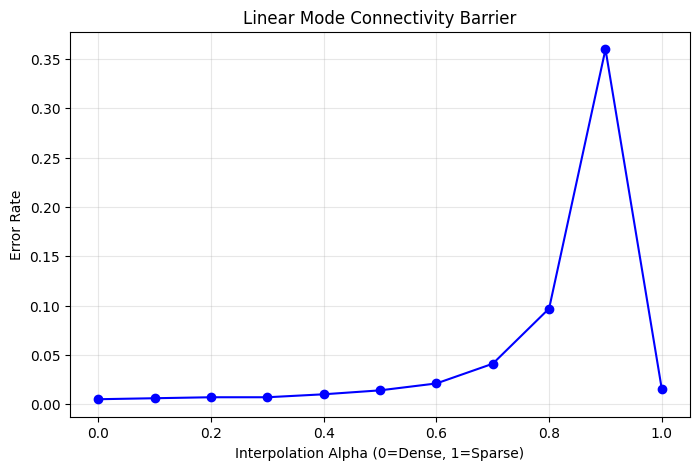

In [32]:
import matplotlib.pyplot as plt

alphas = [r[0] for r in results]
accs = [r[2] for r in results]
errors = [1 - a for a in accs]
cka = [r[3] for r in results]

plt.figure(figsize=(8, 5))
plt.plot(alphas, errors, marker='o', linestyle='-', color='b')
plt.xlabel("Interpolation Alpha (0=Dense, 1=Sparse)")
plt.ylabel("Error Rate")
plt.title("Linear Mode Connectivity Barrier")
plt.grid(True, alpha=0.3)
plt.show()

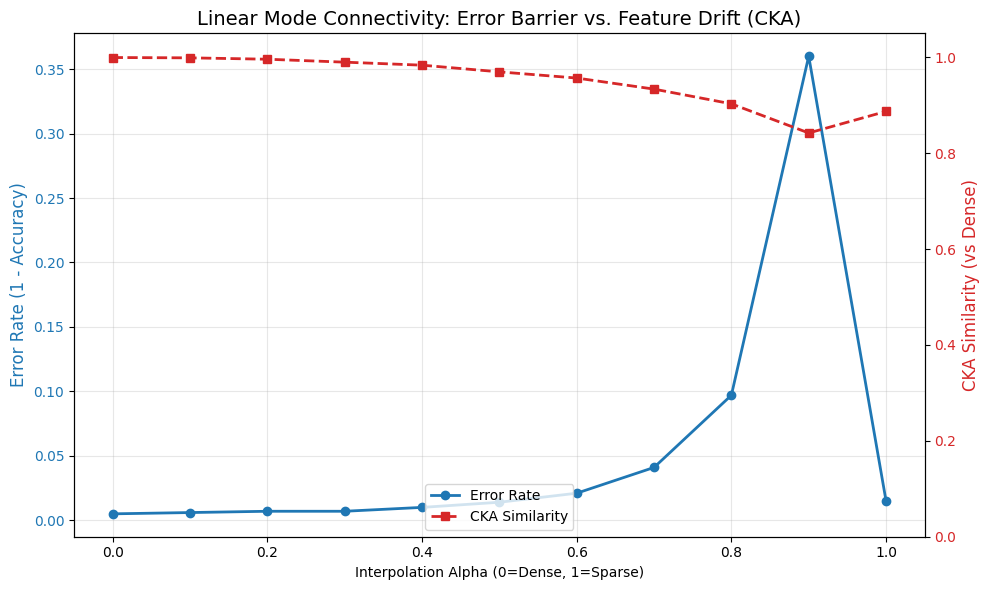

In [37]:
import matplotlib.pyplot as plt

# 1. Extract data (Adjust keys if you used a different structure)
# If using the dictionary format from the last step:
alphas = [r[0] for r in results]
accs = [r[2] for r in results]
errors = [1 - a for a in accs]
ckas = [r[3] for r in results]

# 2. Create the figure and the first axis (Error Rate)
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Interpolation Alpha (0=Dense, 1=Sparse)')
ax1.set_ylabel('Error Rate (1 - Accuracy)', color=color, fontsize=12)
ax1.plot(alphas, errors, marker='o', linestyle='-', linewidth=2, color=color, label='Error Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# 3. Create the second axis (CKA) sharing the same x-axis
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('CKA Similarity (vs Dense)', color=color, fontsize=12)
ax2.plot(alphas, ckas, marker='s', linestyle='--', linewidth=2, color=color, label='CKA Similarity')
ax2.tick_params(axis='y', labelcolor=color)

# Set limits for CKA (Similarity is between 0 and 1)
ax2.set_ylim(0, 1.05) 

# 4. Title and Legend
plt.title("Linear Mode Connectivity: Error Barrier vs. Feature Drift (CKA)", fontsize=14)
fig.tight_layout()

# Add a combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower center')

plt.savefig("lmc_connectivity_analysis.png")
plt.show()

Why the "Asymmetry" at α=0.9?

The most interesting part of your data is the "instability" that kicks in after α=0.6. This is a classic visualization of the Lottery Ticket Hypothesis geometry.

The Dense Basin (α=0.0 to 0.5): The dense model's solution is "thick." You can move quite far away from the local optimum (adding up to 50% of the sparse model's influence) and the network still performs at 98% accuracy.

The Sparse Basin (α=1.0 to 0.8): The sparse model exists in a much narrower, more fragile valley. Moving just 10% away from the "Winning Ticket" (α=0.9) causes accuracy to tank to 55%. This shows that the specific coordination of weights in a sparse mask is much more sensitive to "noise" from the dense weights than vice-versa.

Does this "verify" LMC?

By the strict definition used in the ICML 2020 paper:

If you define LMC as "no significant increase in error": Your model partially passes at the midpoint but fails near the sparse endpoint.

Stability Test: Frankle et al. would argue that your model is not stable at initialization. To achieve true connectivity (a flat line across all α), they suggest you need to rewind to Epoch k (usually a few hundred or thousand iterations into training).

## How to reach "True" Connectivity

If you want to see that 55% accuracy jump up to >95% (eliminating the barrier entirely), the paper suggests:

Train the dense model for a few iterations (k).

Save those weights (W 
k
​	
 ).

Use W 
k
​	
  as your "initialization" for the LTH pruning process.

Run the interpolation again.